In [1]:
from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
import pickle

c:\Users\samny\anaconda3\envs\HLAN\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in all Necessary Data

In [ ]:
train_data_path = ## train_50.csv
dev_data_path = ## dev_50.csv
test_data_path = ## test_50.csv

train_label_path = ## train_code-emb.pt
dev_label_path = ## dev_code-emb.pt
test_label_path = ## test_code-emb.pt

code_model_path = ## code-emb.model

print("Loading data:")
train_df = pd.read_csv(train_data_path)
dev_df = pd.read_csv(dev_data_path)
test_df = pd.read_csv(test_data_path)
print("Number of training notes:",len(train_df))
print("Number of validation notes:",len(dev_df))
print("Number of test notes:",len(test_df))

Loading data:
Number of training notes: 8066
Number of validation notes: 1573
Number of test notes: 1729


In [3]:
train_y = torch.load(train_label_path, weights_only = True)
dev_y = torch.load(dev_label_path, weights_only = True)
test_y = torch.load(test_label_path, weights_only = True)

print("Train label size:",train_y.shape)
print("Dev label size:",dev_y.shape)
print("Test label size:",test_y.shape)

Train label size: torch.Size([8066, 50])
Dev label size: torch.Size([1573, 50])
Test label size: torch.Size([1729, 50])


In [4]:
code_model = Word2Vec.load(code_model_path)

### Label Frequency in data/splits

In [5]:
total_label_dist = np.array(train_y.sum(dim=0) + dev_y.sum(dim = 0) + test_y.sum(dim = 0))
train_label_dist = np.array(train_y.sum(dim = 0))
dev_label_dist = np.array(dev_y.sum(dim = 0))
test_label_dist = np.array(test_y.sum(dim = 0))
indices = np.arange(50)

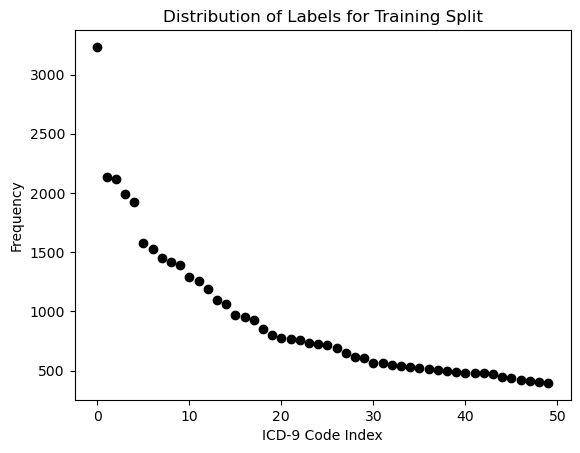

In [25]:
### Plot train distribution
plt.scatter(indices, train_label_dist, color='black')
plt.title('Distribution of Labels for Training Split')
plt.xlabel('ICD-9 Code Index')
plt.ylabel('Frequency')
plt.show()

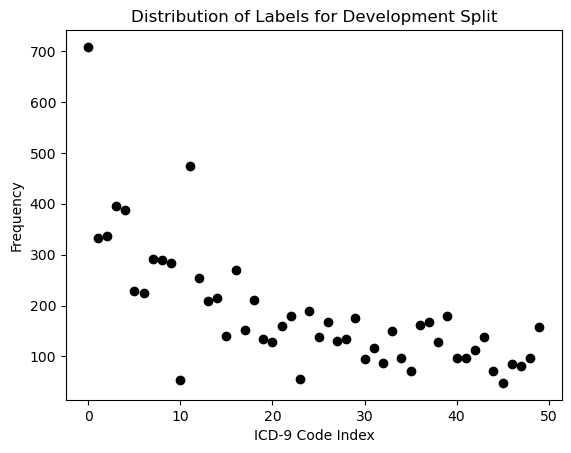

In [26]:
### Plot dev distribution
plt.scatter(indices, dev_label_dist, color='black')
plt.title('Distribution of Labels for Development Split')
plt.xlabel('ICD-9 Code Index')
plt.ylabel('Frequency')
plt.show()

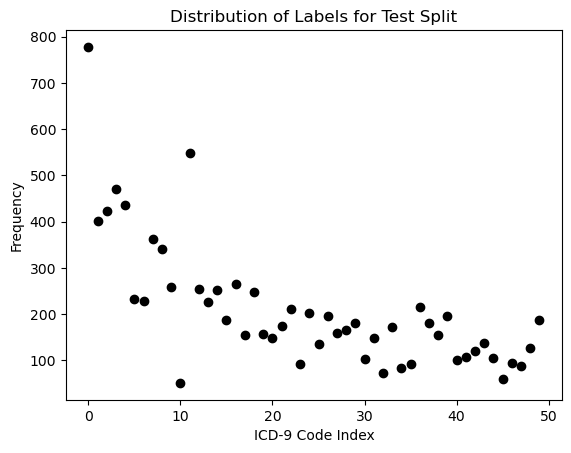

In [27]:
### Plot test distribution
plt.scatter(indices, test_label_dist, color='black')
plt.title('Distribution of Labels for Test Split')
plt.xlabel('ICD-9 Code Index')
plt.ylabel('Frequency')
plt.show()

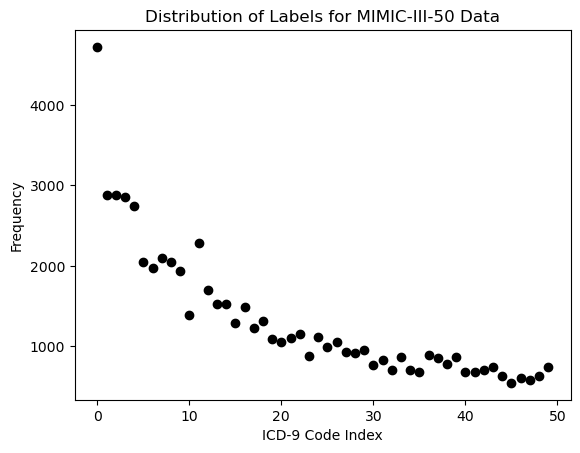

In [29]:
### Plot Total distribution
plt.scatter(indices, total_label_dist, color='black')
plt.title('Distribution of Labels for MIMIC-III-50 Data')
plt.xlabel('ICD-9 Code Index')
plt.ylabel('Frequency')
plt.show()

In [10]:
### Get top 50 labels, counts and names
total_label_dist
top_ten_indices = np.flip(np.argsort(total_label_dist)[-10:])
top_ten_counts = total_label_dist[top_ten_indices]
top_ten_indices

array([ 0,  1,  2,  3,  4, 11,  7,  8,  5,  6], dtype=int64)

In [11]:
label_from_index = code_model.wv.index_to_key[6]
label_from_index

'96.6'

In [12]:
np.where(train_y[:, 6] == 1)[0][0]

6

In [13]:
train_df['LABELS'].iloc[6]

'V15.82;96.6;401.9;96.72'

In [14]:
codes = []
for index in top_ten_indices:
    code = code_model.wv.index_to_key[index]
    codes.append(code)
codes

['401.9',
 '38.93',
 '428.0',
 '427.31',
 '414.01',
 '272.4',
 '584.9',
 '250.00',
 '96.04',
 '96.6']

In [15]:
labels = ['hypertension NOS','venous cath NEC','CHF NOS','atrial fibrillation','crnry athrscl natve vssl','hyperlipidemia NEC/NOS','acute kidney failure NOS',
          'DMII wo cmp nt st uncntr','insert endotracheal tube','entral infus nutrit sub']

In [30]:
stack_counts = np.column_stack([top_ten_indices,top_ten_counts])
top_ten_df = pd.DataFrame(stack_counts, columns = ['Index','Counts'])
top_ten_df['Code'] = codes
top_ten_df['Label'] = labels
top_ten_df

,Index,Counts,Code,Label
0,0,4719,401.9,hypertension NOS
1,1,2874,38.93,venous cath NEC
2,2,2874,428.0,CHF NOS
3,3,2858,427.31,atrial fibrillation
4,4,2744,414.01,crnry athrscl natve vssl
5,11,2282,272.4,hyperlipidemia NEC/NOS
6,7,2102,584.9,acute kidney failure NOS
7,8,2045,250.00,DMII wo cmp nt st uncntr
8,5,2042,96.04,insert endotracheal tube
9,6,1978,96.6,entral infus nutrit sub


In [17]:
### pickle top ten dataframe
with open('top_ten.pkl', 'wb') as f:
    pickle.dump(top_ten_df, f)

### Word Split Tokenization

In [18]:
### BlueBert
bluebert_tokenizer = AutoTokenizer.from_pretrained("bionlp/bluebert_pubmed_mimic_uncased_L-12_H-768_A-12")

### Bioclinical
bioclinical_tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

### BiomedRoberta
roberta_tokenizer = AutoTokenizer.from_pretrained("allenai/biomed_roberta_base")

c:\Users\samny\anaconda3\envs\HLAN\lib\site-packages\huggingface_hub\file_download.py:159: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\samny\.cache\huggingface\hub\models--emilyalsentzer--Bio_ClinicalBERT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [19]:
train_data_path = "C:/Users/samny/NLP/HW_5/Data/train_50.csv"
dev_data_path = "C:/Users/samny/NLP/HW_5/Data/dev_50.csv"
test_data_path = "C:/Users/samny/NLP/HW_5/Data/test_50.csv"

print("Loading data:")
train_df = pd.read_csv(train_data_path)
dev_df = pd.read_csv(dev_data_path)
test_df = pd.read_csv(test_data_path)
print("Number of training notes:",len(train_df))
print("Number of validation notes:",len(dev_df))
print("Number of test notes:",len(test_df))

Loading data:
Number of training notes: 8066
Number of validation notes: 1573
Number of test notes: 1729


In [20]:
### Get doc rep for training, test and dev based on splitting into sentences
num_sent = 100
sent_len = 25
max_len = 2500
train_text = train_df['TEXT']
dev_text = dev_df['TEXT']
test_text = test_df['TEXT']

def split_note_chunks(text, window_size):
    note = text.split(' ')
    sentences = []
    for j in range(0, len(note), window_size):
        sentence = ' '.join(note[j:j+window_size])
        sentences.append(sentence)
    return sentences
train_doc_rep = []
for i in range(len(train_text)):
    text = train_text.iloc[i]
    sentences = split_note_chunks(text, window_size = sent_len)
    train_doc_rep.append(sentences)
dev_doc_rep = []
for i in range(len(dev_text)):
    text = dev_text.iloc[i]
    sentences = split_note_chunks(text, window_size = sent_len)
    train_doc_rep.append(sentences)
test_doc_rep = []
for i in range(len(test_text)):
    text = test_text.iloc[i]
    sentences = split_note_chunks(text, window_size = sent_len)
    test_doc_rep.append(sentences)


In [21]:
def get_token_lens(train_rep, dev_rep, test_rep, tokenizer):
    token_len = []
    for sentences in train_rep:
        for sentence in sentences:
            encoding = tokenizer(sentence, return_tensors = 'pt')
            token_len.append(encoding['input_ids'].shape[1])
    for sentences in dev_rep:
        for sentence in sentences:
            encoding = tokenizer(sentence, return_tensors = 'pt')
            token_len.append(encoding['input_ids'].shape[1])
    for sentences in test_rep:
        for sentence in sentences:
            encoding = tokenizer(sentence, return_tensors = 'pt')
            token_len.append(encoding['input_ids'].shape[1])
    return token_len

In [22]:
bluebert_token_len = get_token_lens(train_doc_rep, dev_doc_rep, test_doc_rep, bluebert_tokenizer)
bioclinical_token_len = get_token_lens(train_doc_rep, dev_doc_rep, test_doc_rep, bioclinical_tokenizer)
roberta_token_len = get_token_lens(train_doc_rep, dev_doc_rep, test_doc_rep, roberta_tokenizer)

In [23]:
print(f'Bluebert max:{np.max(bluebert_token_len)}')
filtered_bluebert_len = [s for s in bluebert_token_len if s > 64]
print(f'Percent bluebert filtered out:{len(filtered_bluebert_len)/len(bluebert_token_len)*100}')
print(f'Bioclinical max:{np.max(bioclinical_token_len)}')
filtered_bioclinical_len = [s for s in bioclinical_token_len if s > 64]
print(f'Percent bioclinical filtered out:{len(filtered_bioclinical_len)/len(bioclinical_token_len)*100}')
print(f'Roberta max:{np.max(roberta_token_len )}')
filtered_roberta_len = [s for s in roberta_token_len  if s > 64]
print(f'Percent Roberta filtered out:{len(filtered_roberta_len)/len(roberta_token_len)*100}')

Bluebert max:174
Percent bluebert filtered out:0.15138405376164998
Bioclinical max:178
Percent bioclinical filtered out:0.4049997359580458
Roberta max:81
Percent Roberta filtered out:0.04197590041691547


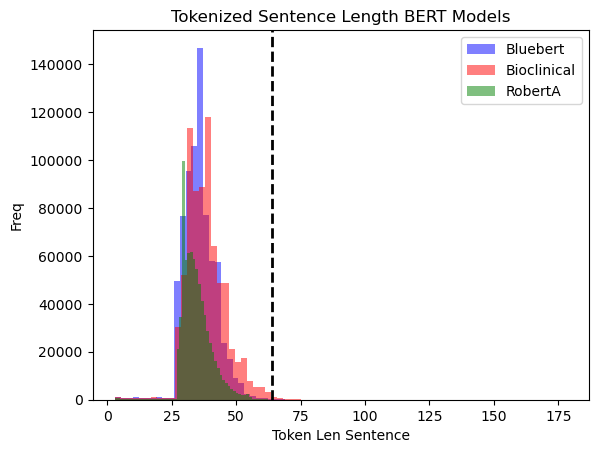

In [24]:
plt.hist(bluebert_token_len, bins = 75, alpha = 0.5, label = "Bluebert", color = 'blue')
plt.hist(bioclinical_token_len, bins = 75, alpha = 0.5, label = "Bioclinical", color = 'red')
plt.hist(roberta_token_len, bins = 75, alpha = 0.5, label = "RobertA", color = 'green')
plt.axvline(x=64, color='black', linestyle='--', linewidth=2)
plt.xlabel('Token Len Sentence')
plt.ylabel('Freq')
plt.title('Tokenized Sentence Length BERT Models')
plt.legend()
plt.show()